In [1]:
# Import modules

import pandas as pd
import lightgbm as lgb
import optuna
import time
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px


In [2]:

all_data = pd.read_excel('../../../Master_v2.xlsx')
print(all_data.head())

     price     priceper  year dateoftransfer         borough  postcode  \
0   490000  10208.33333  2022     2022-01-21  city of london  EC4A 1EP   
1   802500  10422.07792  2015     2015-10-16  city of london  EC1Y 0ST   
2  1200000  15189.87342  2019     2019-08-16  city of london  EC2Y 5AG   
3   626250  12780.61224  2015     2015-03-03  city of london  EC2Y 5AG   
4   938400  14436.92308  2015     2015-01-29  city of london  EC2Y 5AG   

                            transactionid  tfarea area_bin propertytype  ...  \
0  {DE2D0CDF-F797-51EE-E053-6C04A8C00671}    48.0       Q1            F  ...   
1  {23B6165E-9D97-FCF4-E050-A8C0620577FA}    77.0       Q2            F  ...   
2  {93E6821D-E5C2-40FD-E053-6B04A8C0C1DF}    79.0       Q3            F  ...   
3  {637497CC-ECF1-4AFD-B581-E63781F99F4B}    49.0       Q1            F  ...   
4  {74550953-773F-4D4F-A43E-1E79826CD95B}    65.0       Q2            F  ...   

   education    culture   central       ptal  crime_lagged_1yr  \
0  83.00

In [4]:
#Handle missing values
initial_rows = len(all_data.index)
all_data = all_data.dropna()
print(f"Number of rows removed for NA: {initial_rows - len(all_data.index)}")


Number of rows removed for NA: 247500


In [5]:
#Remove outliers >2.0million
all_data = all_data.drop(all_data[all_data['price'] >= 2000000].index)

print(f"Total number of rows for train/test/validation: {len(all_data.index)}")

Total number of rows for train/test/validation: 581471


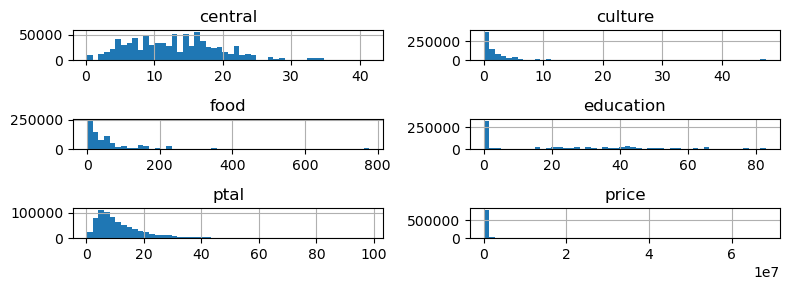

/var/folders/_6/n4f9pfd14lv1q8nl3892x2v80000gn/T/ipykernel_1678/1768789402.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_data = all_data.groupby('year').apply(lambda x: x.sample(frac=1, random_state=42)).reset_index(drop=True)


In [7]:
# Distribution of central and culture
all_data[['central', 'culture', 'food', 'education', 'ptal', 'price']].hist(bins=50, figsize=(8,3))
plt.tight_layout()
plt.show()

# Shuffle rows within years
all_data = all_data.groupby('year').apply(lambda x: x.sample(frac=1, random_state=42)).reset_index(drop=True)

In [12]:
#Define features and target: Uses price as as target and area as predictor
# Create outward postcode (e.g., "SW1A") for location signal
all_data['outward_postcode'] = all_data['postcode'].str.split().str[0]

target = 'priceper'
features = ['propertytype', 'duration', 'education', 'culture', 'central', 'ptal', 'crime_lagged_1yr', 'cpih_lagged_1yr', 'unemployment_lagged_1yr', 'mortgage_lagged_1yr', 'avg_price_lagged_1yr', 'borough', 'outward_postcode']
categorical_features = ['propertytype', 'duration', 'borough', 'outward_postcode']

#Split into train/test based on time
test_data = all_data[all_data['year'] == 2024]
train_full = all_data.drop(all_data[all_data['year'] == 2024].index)
print(f"Length of test data {len(test_data)}")
print(f"Length of training data {len(train_full)}")

# Test split
X_test = test_data[features].copy()
# Convert categorical columns to category dtype (LightGBM requires category, not object/string)
for col in categorical_features:
    X_test[col] = X_test[col].astype('category')
Y_test = test_data[target]

# Train split
X_train_full = train_full[features].copy()
# Convert categorical columns to category dtype (LightGBM requires category, not object/string)
for col in categorical_features:
    X_train_full[col] = X_train_full[col].astype('category')
Y_train_full = train_full[target]
Y_train_full_log = np.log(Y_train_full)

Length of test data 33598
Length of training data 547873


In [96]:
# Time series split function

def time_series_split(df, n_splits=5):
    """
    Generate train/validation splits at year boundaries
    """
    years = sorted(df['year'].unique())
    total_years = len(years)

    splits = []

    for i in range(n_splits):
        # Expanding training window
        train_end_year_idx = total_years - n_splits + i
        train_years = years[:train_end_year_idx]

        # Validation window
        val_start_idx = train_end_year_idx
        val_end_idx = val_start_idx + 1
        val_years = years[val_start_idx:val_end_idx]

        # Note down index, so that the list returned is not abhorrently large
        train_idx = df[df['year'].isin(train_years)].index.values
        val_idx = df[df['year'].isin(val_years)].index.values

        splits.append((train_idx, val_idx))

        print(f"Fold {i+1}: Train on {train_years[0]} to {train_years[-1]}"
              f"({len(train_years)} years, {len(train_idx):,} samples) "
              f"Validate on {val_years[0]} to {val_years[-1]}"
              f"({len(val_years)} years, {len(val_idx):,} samples)")
    
    return splits

In [97]:
#Define optuna objective function with time series split

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'objective': 'huber',
        'alpha': 0.9,
        'random_state': 42,
        'verbosity': -1
    }

    year_splits = time_series_split(train_full)
    cv_scores = []

    for train_idx, val_idx in year_splits:
        X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_log, Y_val_log = Y_train_full_log.iloc[train_idx], Y_train_full_log.iloc[val_idx]
        Y_val_raw = Y_train_full.iloc[val_idx]

        model = lgb.LGBMRegressor(**params) # Accesses the above dict
        model.fit(
            X_train, Y_train_log,
            eval_set=[(X_val, Y_val_log)],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds_log = model.predict(X_val)
        preds = np.exp(preds_log)
        rmse = np.sqrt(mean_squared_error(Y_val_raw, preds))
        cv_scores.append(rmse)

    return np.mean(cv_scores)


In [105]:
from tqdm.auto import tqdm

n_trials = 200
pbar = tqdm(total=n_trials)

def print_trial(study, trial):
    print(f"Trial {trial.number}: RMSE £{trial.value:,.2f}")
    pbar.set_postfix_str(f"best RMSE £{study.best_value:,.2f}")
    pbar.update(1)

# Fresh study each run
study = optuna.create_study(direction='minimize')

# Run optimization
study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[print_trial],
)

pbar.close()
print(f"Best RMSE: £{study.best_value:,.2f}")
print(f"Best parameters: {study.best_params}")

  0%|          | 0/200 [00:00<?, ?it/s]

Fold 1: Train on 2015 to 2018(4 years, 368,241 samples) Validate on 2019 to 2019(1 years, 78,521 samples)
Fold 2: Train on 2015 to 2019(5 years, 446,762 samples) Validate on 2020 to 2020(1 years, 72,679 samples)
Fold 3: Train on 2015 to 2020(6 years, 519,441 samples) Validate on 2021 to 2021(1 years, 105,771 samples)
Fold 4: Train on 2015 to 2021(7 years, 625,212 samples) Validate on 2022 to 2022(1 years, 90,233 samples)
Fold 5: Train on 2015 to 2022(8 years, 715,445 samples) Validate on 2023 to 2023(1 years, 65,231 samples)
Trial 0: RMSE £149,161.75
Fold 1: Train on 2015 to 2018(4 years, 368,241 samples) Validate on 2019 to 2019(1 years, 78,521 samples)
Fold 2: Train on 2015 to 2019(5 years, 446,762 samples) Validate on 2020 to 2020(1 years, 72,679 samples)
Fold 3: Train on 2015 to 2020(6 years, 519,441 samples) Validate on 2021 to 2021(1 years, 105,771 samples)
Fold 4: Train on 2015 to 2021(7 years, 625,212 samples) Validate on 2022 to 2022(1 years, 90,233 samples)
Fold 5: Train on 2

Best trial number: 104
Best RMSE: 138722.08221921435
Best parameters: {'n_estimators': 976, 'learning_rate': 0.09133438802132478, 'num_leaves': 138, 'max_depth': 13, 'min_child_samples': 58, 'subsample': 0.8736812145046358, 'colsample_bytree': 0.6554514236629634}


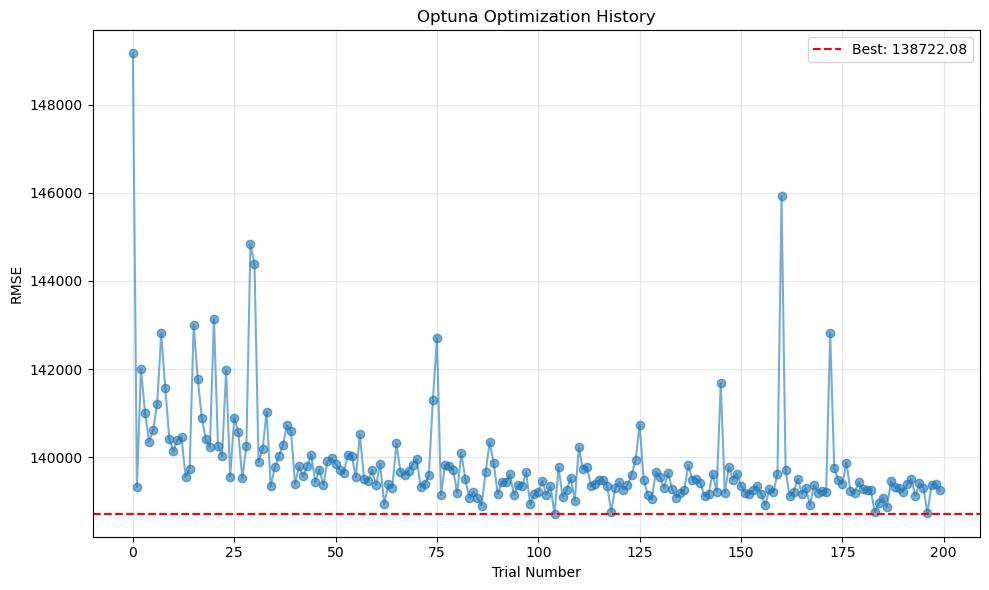

In [106]:
# 1. Find which trial had the best params
print(f"Best trial number: {study.best_trial.number}")
print(f"Best RMSE: {study.best_value}")
print(f"Best parameters: {study.best_params}")

# 2. Plot trial vs value (optimization history)

trial_numbers = [trial.number for trial in study.trials]
trial_values = [trial.value for trial in study.trials]

plt.figure(figsize=(10, 6))
plt.plot(trial_numbers, trial_values, 'o-', alpha=0.6)
plt.axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.2f}')
plt.xlabel('Trial Number')
plt.ylabel('RMSE')
plt.title('Optuna Optimization History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Train final model with best params

best_model = lgb.LGBMRegressor(
    objective='huber',
    alpha=0.9,
)
best_model.fit(X_train_full, Y_train_full_log, categorical_feature=categorical_features)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 547873, number of used features: 13
[LightGBM] [Info] Start training from score 8.715416


LGBMRegressor(alpha=0.9, objective='huber')

In [16]:
#Evaluate model performance
Y_pred_log = best_model.predict(X_test)
Y_pred = np.exp(Y_pred_log)
rmse = mean_squared_error(Y_test, Y_pred, squared=False)
mean_price = Y_test.mean()
rmse_relative = (rmse / mean_price) * 100
mae = mean_absolute_error(Y_test, Y_pred)
mae_relative = (mae / mean_price) * 100
r2 = r2_score(Y_test, Y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"Mean priceper: {mean_price:.2f}")
print(f"RMSE as percentage of mean priceper: {rmse_relative:.2f}%")
print(f"MAE: {mae:.2f}")
print(f"MAE as percentage of mean priceper: {mae_relative:.2f}%")
print(f"R-squared: {r2:.2f}")

RMSE: 1904.71
Mean priceper: 6934.70
RMSE as percentage of mean priceper: 27.47%
MAE: 1113.43
MAE as percentage of mean priceper: 16.06%
R-squared: 0.51


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [129]:
# Calculate tolerance levels
percentage_errors = np.abs((Y_test - Y_pred) / Y_test) * 100

tolerances = [5, 10, 15, 20]

for tol in tolerances:
    within_tol = (percentage_errors <= tol).sum()
    pct = (within_tol / len(Y_test)) * 100
    print(f"Within {tol:2d}%: {pct:5.1f}% ({within_tol}/{len(Y_test)} properties)")



Within  5%:  26.3% (8827/33598 properties)
Within 10%:  49.1% (16511/33598 properties)
Within 15%:  66.2% (22240/33598 properties)
Within 20%:  78.2% (26284/33598 properties)


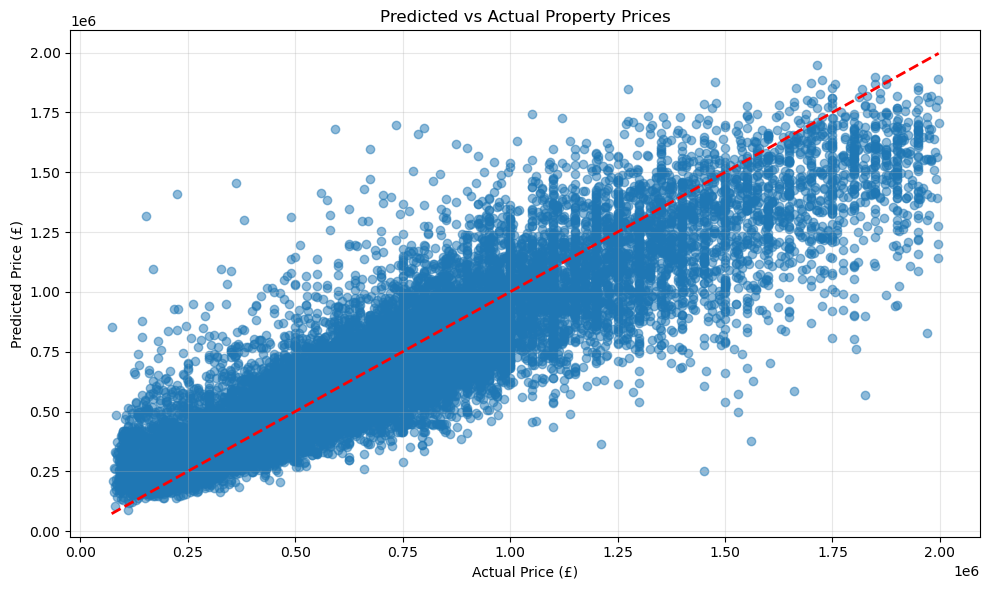

In [110]:
# Plot predicted vs actual
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.title('Predicted vs Actual Property Prices')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

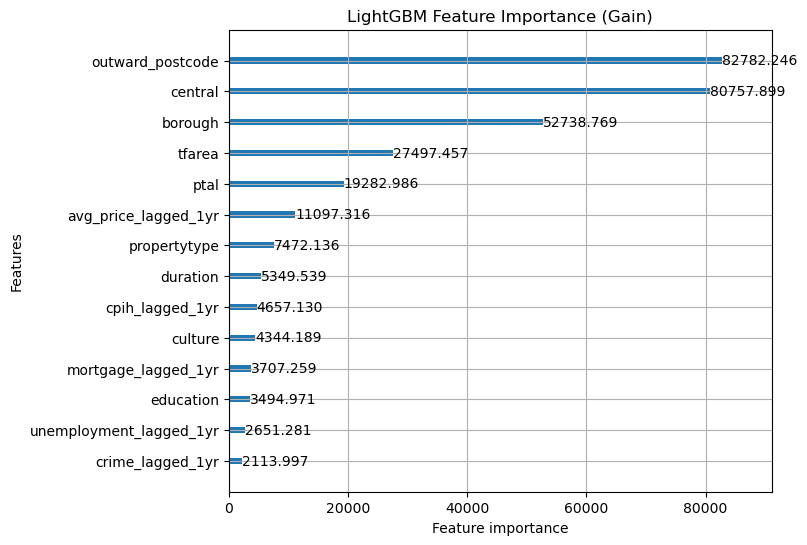

In [11]:
#Feature importance (Gain)
lgb.plot_importance(best_model, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

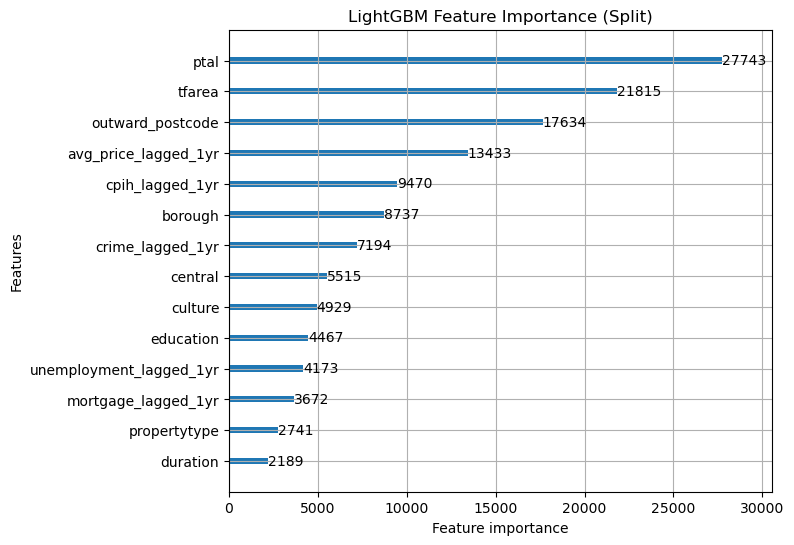

In [112]:
#Feature importance (Split)
lgb.plot_importance(best_model, importance_type="split", figsize=(7,6), title="LightGBM Feature Importance (Split)")
plt.show()

In [ ]:
# Error exploration

# Create df
results_df = (
    test_data[['tfarea', 'year', 'postcode', 'priceper']]
    .copy()
    .join(pd.Series(Y_pred, index=test_data.index, name='predictedpriceper'))
)
results_df = results_df.rename(columns={'priceper': 'actualpriceper'})

# compute absolute percentage error
results_df['ape'] = (results_df.actualpriceper - results_df.predictedpriceper).abs() / results_df.actualpriceper

# compute signed percentage error
results_df['spe'] = (results_df.actualpriceper - results_df.predictedpriceper) / results_df.actualpriceper

print(results_df.head())


        tfarea  year postcode  actualprice  predictedprice       ape       spe
780676    87.4  2024  N14 5HT       400000   479700.985394  0.199252 -0.199252
780677    66.0  2024  SM5 4QJ       557000   422298.815823  0.241833  0.241833
780678    47.0  2024  HA3 0BQ       195000   192532.242437  0.012655  0.012655
780679    73.0  2024  E17 9RG       454000   497422.331589  0.095644 -0.095644
780680   116.0  2024  E11 2QB      1230000   950821.592676  0.226974  0.226974


In [114]:
# Error distributiuon

results_df['ape'].describe()


count    3.996600e+04
mean     1.600864e-01
std      2.514391e-01
min      2.089551e-07
25%      4.869520e-02
50%      1.054310e-01
75%      1.905240e-01
max      1.070622e+01
Name: ape, dtype: float64

In [115]:
results_df['spe'].describe()

count    39966.000000
mean        -0.021916
std          0.297270
min        -10.706224
25%         -0.090277
50%          0.020251
75%          0.116390
max          0.827862
Name: spe, dtype: float64

Mean is a lot higher than median, so we know that there's a right skew. large outliers dominate RMSE 
- try log target
- huber/segmentation

In [116]:
fig = px.histogram(results_df, x='ape', nbins=80, log_y=True)
fig.update_layout(
    xaxis_title='Absolute Percentage Error (APE)',
    yaxis_title='Count'
)
fig.show()

In [117]:
# RMSE by APE decile

results_df["ape_decile"] = pd.qcut(results_df.ape, 10, labels=False)

rmse_by_decile = (
    results_df.groupby("ape_decile")
      .apply(lambda x: np.sqrt(((x.actualprice - x.predictedprice) ** 2).mean()))
)

decile_summary = (
    results_df.groupby("ape_decile")
    .agg(
        n=("ape", "size"),
        ape_min=("ape", "min"),
        ape_max=("ape", "max"),
        ape_mean=("ape", "mean"),
    )
    .join(rmse_by_decile.rename("rmse"))
)

decile_summary


,n,ape_min,ape_max,ape_mean,rmse
ape_decile,,,,,
0,3997,2.089551e-07,0.018980,0.009607,7016.218346
1,3997,1.900133e-02,0.038596,0.028932,18701.245534
2,3996,3.859655e-02,0.059164,0.048788,31111.292124
3,3997,5.917006e-02,0.081348,0.069974,44965.064336
4,3996,8.134946e-02,0.105430,0.093226,61691.242473
5,3997,1.054314e-01,0.133848,0.119117,81382.127644
6,3996,1.338724e-01,0.169006,0.150675,108389.991487
7,3997,1.690135e-01,0.216578,0.191444,142928.994857
8,3996,2.165849e-01,0.301667,0.253848,197966.008751


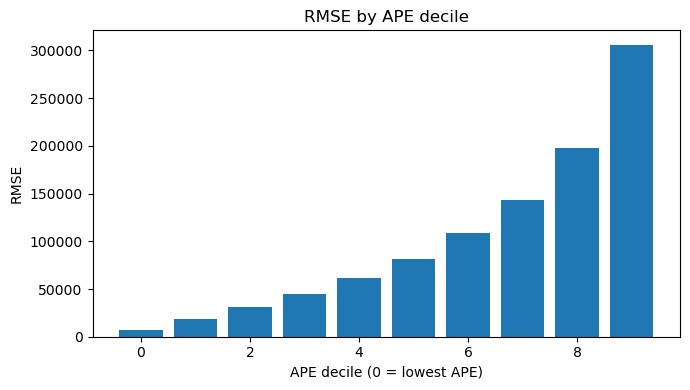

In [118]:
plt.figure(figsize=(7,4))
plt.bar(decile_summary.index, decile_summary["rmse"])
plt.xlabel("APE decile (0 = lowest APE)")
plt.ylabel("RMSE")
plt.title("RMSE by APE decile")
plt.tight_layout()
plt.show()

In [119]:
# Error by price bins

results_df['price_bin'] = pd.qcut(results_df.actualprice, 20, labels=False)
pricebins = results_df.groupby('price_bin')['ape'].mean()
pricebins

price_bin
0     0.627341
1     0.186166
2     0.156236
3     0.143594
4     0.121739
5     0.113335
6     0.108376
7     0.111736
8     0.113623
9     0.121670
10    0.115875
11    0.124104
12    0.126096
13    0.128554
14    0.132150
15    0.144407
16    0.147712
17    0.149341
18    0.149893
19    0.168159
Name: ape, dtype: float64

In [120]:
results_df['price_bin'] = pd.qcut(results_df.actualprice, 20, labels=False)
pricebins = results_df.groupby('price_bin')['spe'].mean()
pricebins

price_bin
0    -0.603113
1    -0.118559
2    -0.078177
3    -0.071506
4    -0.048554
5    -0.034308
6    -0.017619
7    -0.007312
8     0.002053
9     0.002593
10    0.022796
11    0.031040
12    0.037814
13    0.033301
14    0.042574
15    0.052466
16    0.060806
17    0.055687
18    0.069435
19    0.148441
Name: spe, dtype: float64

In [121]:
results_df["area_q"] = pd.qcut(results_df.tfarea, 20, labels=False)

areabins = results_df.groupby("area_q")["ape"].mean()
areabins


area_q
0     0.175506
1     0.187787
2     0.195292
3     0.177998
4     0.172792
5     0.174120
6     0.159040
7     0.178408
8     0.170561
9     0.155807
10    0.154458
11    0.146470
12    0.138335
13    0.140783
14    0.149281
15    0.144633
16    0.144651
17    0.138550
18    0.148171
19    0.146810
Name: ape, dtype: float64

In [122]:
results_df["area_q"] = pd.qcut(results_df.tfarea, 20, labels=False)

areabins = results_df.groupby("area_q")["spe"].mean()
areabins

area_q
0    -0.033466
1    -0.030760
2    -0.063609
3    -0.046683
4    -0.025080
5    -0.037132
6    -0.018884
7    -0.043859
8    -0.042149
9    -0.022310
10   -0.028193
11   -0.013216
12    0.007482
13   -0.000235
14   -0.005221
15   -0.007186
16   -0.005633
17    0.002629
18   -0.016891
19   -0.009405
Name: spe, dtype: float64